# Day 33 — Out-of-Bag Evaluation & Random Forests

- Understand Out-of-Bag (OOB) evaluation.
- Understand random patches and random subspaces.
- Build and evaluate Random Forest classifiers.
- Understand Random Forest randomness and diversity.
- Compare Random Forests with Extra-Trees.
- Explore the bias/variance trade-off caused by additional randomness.
- Inspect feature importance.


## 1. Imports and setup

This notebook uses scikit-learn's built-in datasets, so no external dataset download is required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup complete')

Setup complete


## 2. Quick theory — Bootstrap sampling and OOB evaluation

In **bagging**, each estimator is trained on a bootstrap sample drawn **with replacement** from the training data.

A training instance that is not selected for a particular estimator is **out-of-bag (OOB)** for that estimator.

The forest can use predictions from estimators for which an observation was OOB to estimate its performance. This means we can get a useful validation estimate without creating a separate validation set.

A useful rule of thumb is that a bootstrap sample contains about **63.2% unique observations** on average, leaving about **36.8%** OOB for a given tree.

In [2]:
# Demonstrate the approximate OOB fraction for one bootstrap sample
n = 1000
sample = np.random.randint(0, n, size=n)
unique_fraction = len(np.unique(sample)) / n
oob_fraction = 1 - unique_fraction

print(f'Unique observations in bootstrap sample: {unique_fraction:.3f}')
print(f'OOB observations: {oob_fraction:.3f}')
print('The theoretical expected OOB fraction is approximately 36.8%.')

Unique observations in bootstrap sample: 0.615
OOB observations: 0.385
The theoretical expected OOB fraction is approximately 36.8%.


## 3. Build a baseline Decision Tree

We first create a simple classifier. Later, we will compare one tree with an ensemble of trees.

In [3]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training samples:', len(X_train))
print('Test samples:', len(X_test))

Training samples: 750
Test samples: 250


In [4]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)
print('Decision Tree accuracy:', accuracy_score(y_test, tree_pred))

Decision Tree accuracy: 0.948


## 4. Bagging with Decision Trees

Bagging trains many base estimators on different bootstrap samples and aggregates their predictions.

Here we explicitly create a bagging classifier so you can see the connection between bagging and Random Forests.

In [5]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)
print('Bagging test accuracy:', accuracy_score(y_test, bag_pred))
print('Bagging OOB score:', bagging.oob_score_)

Bagging test accuracy: 0.972
Bagging OOB score: 0.932


### Key observation

The `oob_score_` attribute is an estimate of generalization performance obtained from OOB observations. Compare it with the held-out test accuracy, but remember that the test set remains useful as an independent final evaluation.

## 5. Random Forest

A Random Forest is an ensemble of Decision Trees with additional randomness in feature selection at each split.

Important parameters:
- `n_estimators`: number of trees.
- `max_features`: number/fraction of features considered at each split.
- `bootstrap`: whether bootstrap samples are used.
- `oob_score`: whether OOB evaluation is calculated.
- `max_depth`: controls tree depth and complexity.

In [6]:
forest = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)
print('Random Forest test accuracy:', accuracy_score(y_test, forest_pred))
print('Random Forest OOB score:', forest.oob_score_)

Random Forest test accuracy: 0.968
Random Forest OOB score: 0.9373333333333334


## 6. Compare single tree, bagging, and Random Forest

In [7]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Bagging', 'Random Forest'],
    'Test Accuracy': [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, bag_pred),
        accuracy_score(y_test, forest_pred)
    ],
    'OOB Score': [np.nan, bagging.oob_score_, forest.oob_score_]
})

comparison

,Model,Test Accuracy,OOB Score
0,Decision Tree,0.948,NaN
1,Bagging,0.972,0.932000
2,Random Forest,0.968,0.937333


## 7. Random subspaces

**Random Subspaces** means introducing randomness by selecting a subset of features rather than always considering all features.

In scikit-learn's Random Forest, `max_features` controls the number of features considered when looking for the best split.

With `max_features='sqrt'`, classification trees consider a random subset of features at each split.

In [8]:
# Iris has 4 features, making feature-subset behavior easy to inspect.
# This example compares different max_features settings.

iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

Xtr, Xte, ytr, yte = train_test_split(
    X_iris, y_iris,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_iris
)

results = []
for max_features in [1, 2, 3, 4, 'sqrt']:
    clf = RandomForestClassifier(
        n_estimators=200,
        max_features=max_features,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    clf.fit(Xtr, ytr)
    results.append({
        'max_features': str(max_features),
        'test_accuracy': clf.score(Xte, yte),
        'oob_score': clf.oob_score_
    })

pd.DataFrame(results)

,max_features,test_accuracy,oob_score
0,1,0.921053,0.955357
1,2,0.894737,0.955357
2,3,0.947368,0.955357
3,4,0.921053,0.946429
4,sqrt,0.894737,0.955357


## 8. Random patches

**Random Patches** combines:

- random subsets of training instances, and
- random subsets of features.

Conceptually:

`Random Patches = random samples + random features`

This can be useful when datasets contain many instances and many features. The exact implementation depends on the ensemble method and API being used.

## 9. Extra-Trees

**Extra-Trees (Extremely Randomized Trees)** introduce more randomness into tree construction. Instead of searching as extensively for the best threshold, candidate thresholds are randomized and the best among those candidates is selected.

The additional randomness can reduce variance and increase diversity, although it can sometimes increase bias.

In [9]:
extra = ExtraTreesClassifier(
    n_estimators=300,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

extra.fit(X_train, y_train)
extra_pred = extra.predict(X_test)

print('Extra-Trees test accuracy:', accuracy_score(y_test, extra_pred))

Extra-Trees test accuracy: 0.968


## 10. Random Forest vs Extra-Trees

In [10]:
tree_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Extra-Trees'],
    'Test Accuracy': [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred),
        accuracy_score(y_test, extra_pred)
    ]
})

tree_comparison

,Model,Test Accuracy
0,Decision Tree,0.948
1,Random Forest,0.968
2,Extra-Trees,0.968


## 11. Feature importance

Random Forests can estimate feature importance using the total impurity reduction attributed to features across the trees.

Treat impurity-based importance as a useful diagnostic rather than absolute proof that a feature is causally important.

### Remember

| Model | Main source of randomness |
|---|---|
| Decision Tree | None/very little |
| Bagging | Bootstrap samples |
| Random Forest | Bootstrap samples + random feature selection |
| Extra-Trees | Random feature selection + randomized thresholds |


In [11]:
feature_importance = pd.Series(
    forest.feature_importances_,
    index=['feature_1', 'feature_2']
).sort_values(ascending=False)

feature_importance

feature_2    0.535701
feature_1    0.464299
dtype: float64

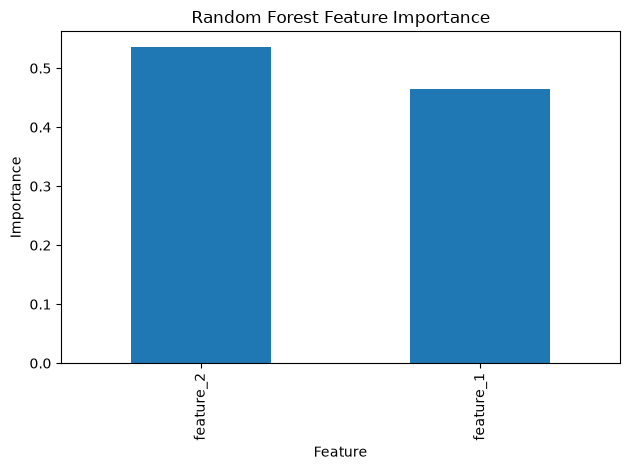

In [12]:
feature_importance.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

## 12. Bias vs variance — intuition

A single deep Decision Tree can have low training error but high variance.

Random Forests reduce variance by averaging many diverse trees. More randomness can make individual trees less powerful, which can increase bias, but it can also decrease correlation between trees and reduce ensemble variance.

The goal is not to make every tree perfect. The goal is to build an ensemble whose errors are not strongly correlated.

In [13]:
# Observe how the number of trees affects test and OOB performance.

rows = []
for n_trees in [5, 10, 25, 50, 100, 200, 500]:
    clf = RandomForestClassifier(
        n_estimators=n_trees,
        max_features='sqrt',
        bootstrap=True,
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    rows.append({
        'n_estimators': n_trees,
        'test_accuracy': clf.score(X_test, y_test),
        'oob_score': clf.oob_score_
    })

pd.DataFrame(rows)

c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\Puneeth\Desktop\dev-studies\2026 07 13 ML learning\machine-learning-from-scratch\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,test_accuracy,oob_score
0,5,0.960,0.878667
1,10,0.964,0.921333
2,25,0.968,0.932000
3,50,0.976,0.929333
4,100,0.972,0.929333
5,200,0.972,0.936000
6,500,0.968,0.934667


## 13. Confusion matrix and classification report

In [14]:
print('Confusion matrix:')
print(confusion_matrix(y_test, forest_pred))

print('\nClassification report:')
print(classification_report(y_test, forest_pred))

Confusion matrix:
[[120   5]
 [  3 122]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       125
           1       0.96      0.98      0.97       125

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250

